In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = np.zeros((400, 600), dtype=np.uint8)
cv2.rectangle(image, (100, 100), (500, 300), 255, -1)
cv2.circle(image, (300, 200), 80, 180, -1)
image = cv2.GaussianBlur(image, (3, 3), 0)

print("Image loaded successfully. Shape:", image.shape)


# Simple Gradient
grad_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
gradient_magnitude = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Sobel Operator
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_magnitude = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Laplacian Operator
laplacian = cv2.Laplacian(image, cv2.CV_64F)

# Canny Edge Detector (default thresholds)
canny = cv2.Canny(image, 100, 200)

Image loaded successfully. Shape: (400, 600)


In [5]:
# Exercise 1: Change Canny thresholds
canny_low = cv2.Canny(image, 50, 150)
canny_high = cv2.Canny(image, 150, 250)

In [6]:
# Exercise 2: Apply Gaussian blur before Sobel and Laplacian
blurred = cv2.GaussianBlur(image, (5, 5), 0)

In [7]:
# Sobel after blur
sobel_blur_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sobel_blur_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
sobel_blurred = np.sqrt(sobel_blur_x**2 + sobel_blur_y**2)
sobel_blurred = cv2.normalize(sobel_blurred, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

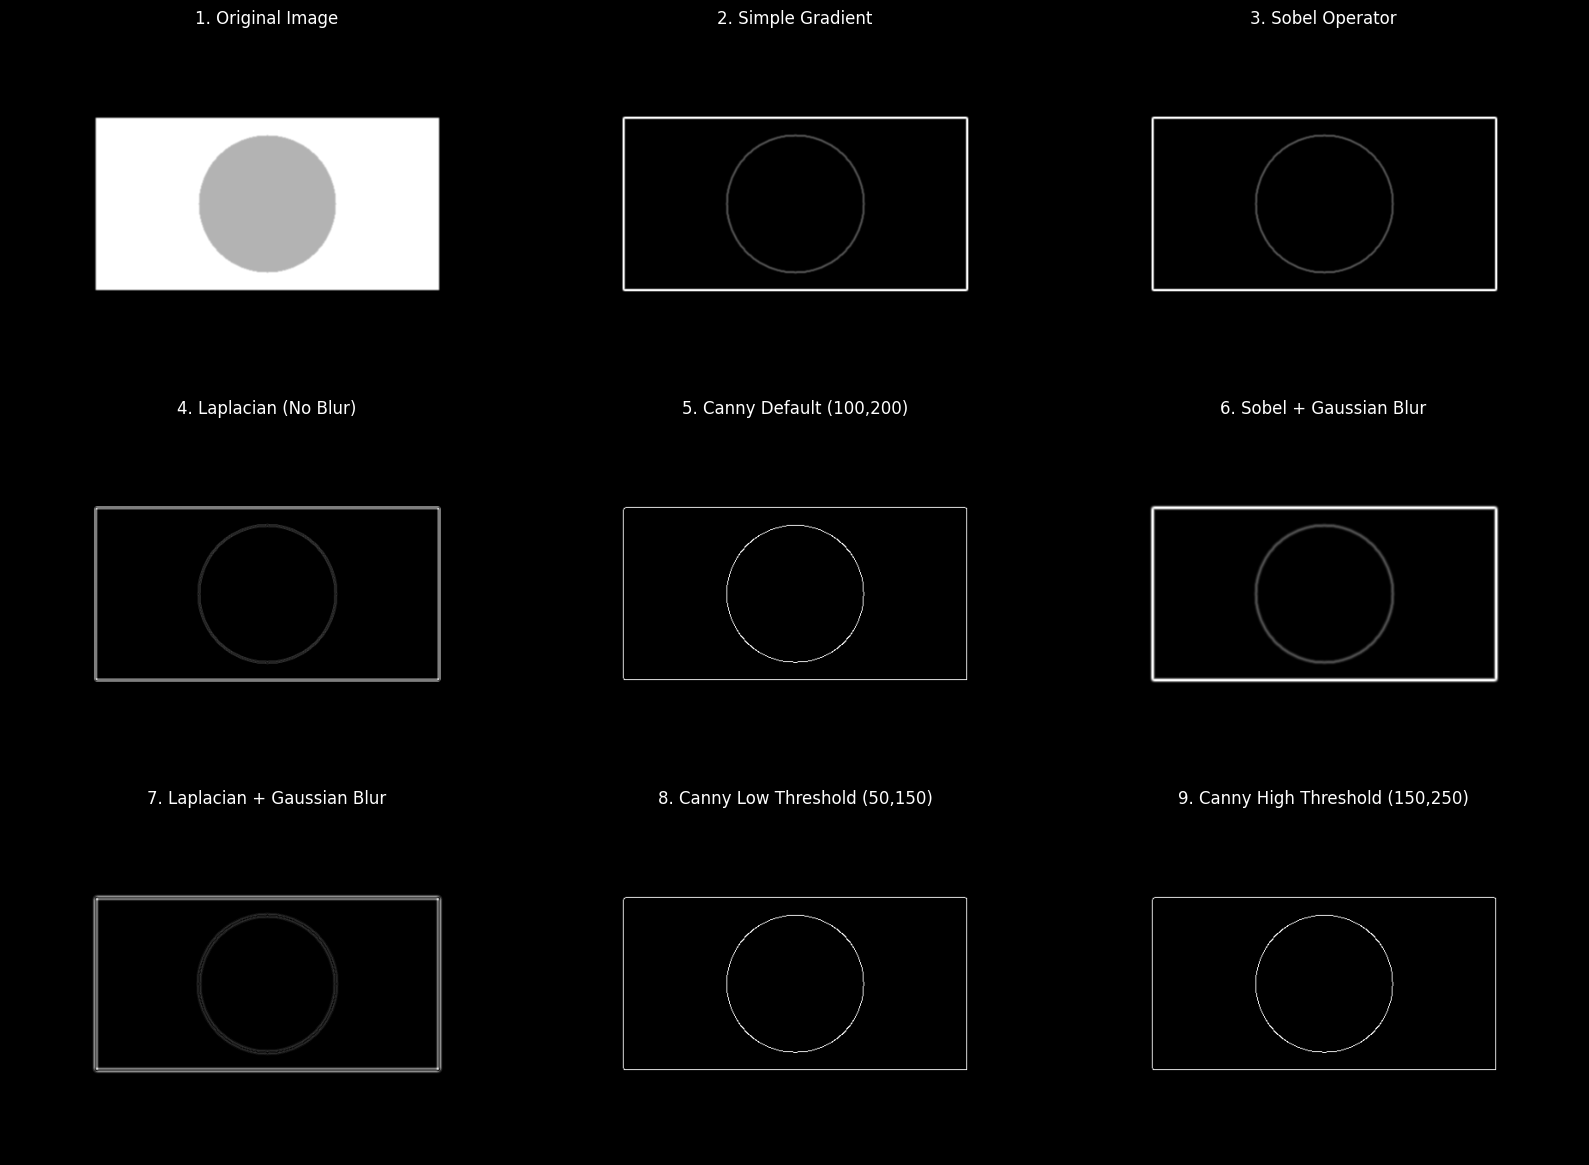

In [9]:
# Laplacian after blur
lap_blurred = cv2.Laplacian(blurred, cv2.CV_64F)

plt.figure(figsize=(16, 12))

plt.subplot(3, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('1. Original Image')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('2. Simple Gradient')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('3. Sobel Operator')
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('4. Laplacian (No Blur)')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(canny, cmap='gray')
plt.title('5. Canny Default (100,200)')
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(sobel_blurred, cmap='gray')
plt.title('6. Sobel + Gaussian Blur')
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(np.abs(lap_blurred), cmap='gray')
plt.title('7. Laplacian + Gaussian Blur')
plt.axis('off')

plt.subplot(3, 3, 8)
plt.imshow(canny_low, cmap='gray')
plt.title('8. Canny Low Threshold (50,150)')
plt.axis('off')

plt.subplot(3, 3, 9)
plt.imshow(canny_high, cmap='gray')
plt.title('9. Canny High Threshold (150,250)')
plt.axis('off')

plt.tight_layout()
plt.show()
